In [2]:
I# using pandas for data manipulation and analysis
import pandas as pd

# using matplotlib and seaborn for creating charts and graphs
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Setting a nice visual theme for the graphs
sns.set_theme(style="whitegrid")

# Loading the data into a DataFrame called 'df'
df = pd.read_csv('train.csv')

# Displaying the first 5 rows to understand what the data looks like
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Getting a summary of the dataset (row count, column data types)
df.info()

# Checking exactly how many missing (null) values exist in each column
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# 1. Dropping the 'Cabin' column
df = df.drop('Cabin', axis=1)

# 2. Filling missing 'Age' values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# 3. Filling missing 'Embarked' values with the mode (most frequent value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Verifying that all missing values have been handled
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


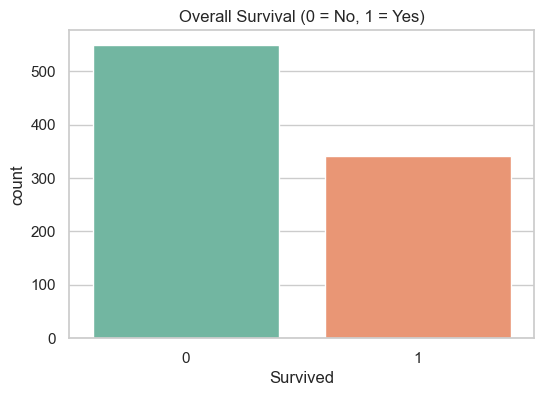

In [9]:
# Exploratory Data Analysis(EDA)

# Pattern 1: Overall Survival Rate

plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='Set2', hue='Survived', legend=False)
plt.title('Overall Survival (0 = No, 1 = Yes)')
plt.show()

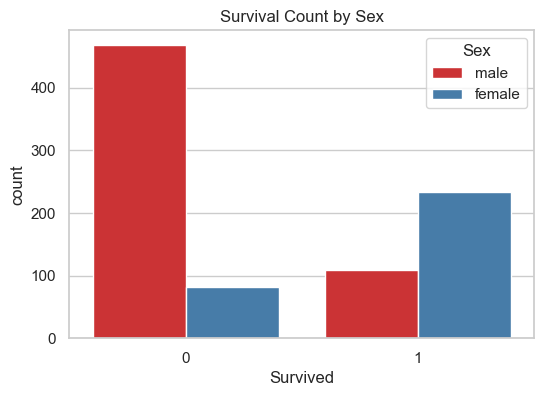

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [10]:
# Pattern 2: Relationship between Gender and Survival

plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Sex', data=df, palette='Set1')
plt.title('Survival Count by Sex')
plt.show()

# Calculating exact survival percentages by sex
print(df.groupby('Sex')['Survived'].mean() * 100)

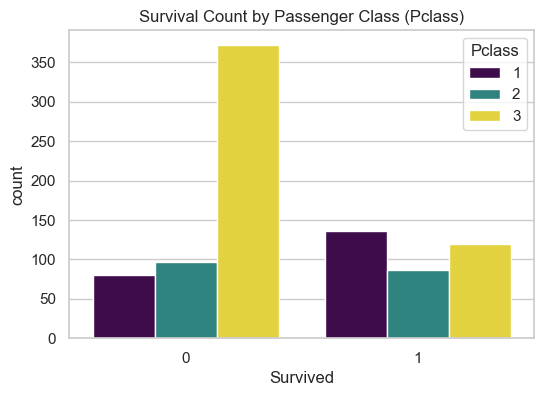

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [11]:
# Pattern 3: Socio-Economic Status(Passenger Class)

plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Pclass', data=df, palette='viridis')
plt.title('Survival Count by Passenger Class (Pclass)')
plt.show()

# Calculate exact survival percentages by Class
print(df.groupby('Pclass')['Survived'].mean() * 100)